### Manual implementation of FEM

Solve the Poisson equation in two dimensions within the unit square with homogeneous Dirichlet boundary conditions

In [1]:
# Importing libraries
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

In [2]:
def generate_mesh(n_intervals):
    
    # Generate node coordinates
    x_coords = np.linspace(0, 1, n_intervals + 1)
    y_coords = np.linspace(0, 1, n_intervals + 1)
    X, Y = np.meshgrid(x_coords, y_coords, indexing = 'ij')
    nodes = np.column_stack([X.ravel(), Y.ravel()])
    
    # Generate triangles
    N_elements = 2 * n_intervals * n_intervals
    elements = np.zeros((N_elements, 3), dtype = np.int32)
    
    # Create index arrays for operations
    i_indices, j_indices = np.meshgrid(np.arange(n_intervals), np.arange(n_intervals), indexing = 'ij')
    i_indices = i_indices.ravel()
    j_indices = j_indices.ravel()
    
    n_nodes_side = n_intervals + 1
    
    # Calculate node indices for all squares at once
    n0 = j_indices * n_nodes_side + i_indices
    n1 = j_indices * n_nodes_side + i_indices + 1
    n2 = (j_indices + 1) * n_nodes_side + i_indices
    n3 = (j_indices + 1) * n_nodes_side + i_indices + 1
    
    # Assign triangles
    elements[0::2, 0] = n0
    elements[0::2, 1] = n1
    elements[0::2, 2] = n2
    
    elements[1::2, 0] = n1
    elements[1::2, 1] = n3
    elements[1::2, 2] = n2
    
    # Identify boundary nodes
    x, y = nodes[:, 0], nodes[:, 1]
    boundary_mask = (np.abs(x) < 1e-10) | (np.abs(x - 1) < 1e-10) | (np.abs(y) < 1e-10) | (np.abs(y - 1) < 1e-10)
    boundary_nodes = np.where(boundary_mask)[0]
    
    return nodes, elements, boundary_nodes

def compute_element_stiffness_batch(triangles_coords):
    
    # Extract vertices coordinates
    x1, y1 = triangles_coords[:, 0, 0], triangles_coords[:, 0, 1]
    x2, y2 = triangles_coords[:, 1, 0], triangles_coords[:, 1, 1]
    x3, y3 = triangles_coords[:, 2, 0], triangles_coords[:, 2, 1]
    
    # Calculate triangle areas using cross product
    areas = 0.5 * np.abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    
    # Add small epsilon to avoid division by zero
    areas = np.maximum(areas, 1e-12)
    
    # Calculate gradients of basis functions
    b1 = y2 - y3
    b2 = y3 - y1
    b3 = y1 - y2
    
    c1 = x3 - x2
    c2 = x1 - x3
    c3 = x2 - x1
    
    # Initialize output array
    N_elements = triangles_coords.shape[0]
    K_e_all = np.zeros((N_elements, 3, 3))
    
    # Compute stiffness matrices using broadcasting
    inv_4area = 1.0 / (4.0 * areas)  # Shape: (N_elements,)
    
    # Fill the upper triangular part and symmetrize
    for i in range(3):
        for j in range(i, 3):
            if i == 0:
                b_i, c_i = b1, c1
            elif i == 1:
                b_i, c_i = b2, c2
            else:  # i == 2
                b_i, c_i = b3, c3
                
            if j == 0:
                b_j, c_j = b1, c1
            elif j == 1:
                b_j, c_j = b2, c2
            else:  # j == 2
                b_j, c_j = b3, c3
            
            K_e_all[:, i, j] = (b_i * b_j + c_i * c_j) * inv_4area
            if i != j:
                K_e_all[:, j, i] = K_e_all[:, i, j]
    
    return K_e_all, areas

def assemble_global_system(nodes, elements, boundary_nodes, f_func):
    N_nodes = nodes.shape[0]
    N_elements = elements.shape[0]
    
    # Identify free nodes
    all_nodes = np.arange(N_nodes, dtype = np.int32)
    free_nodes = np.setdiff1d(all_nodes, boundary_nodes)
    N_free = len(free_nodes)
    
    # Create mapping from global index to reduced index
    global_to_free = np.full(N_nodes, -1, dtype = np.int32)
    global_to_free[free_nodes] = np.arange(N_free, dtype = np.int32)
    
    # Get triangle coordinates
    triangle_coords = nodes[elements]
    
    # Batch compute all element stiffness matrices and areas
    K_e_all, areas = compute_element_stiffness_batch(triangle_coords)
    
    # Calculate centroids
    centroids = np.mean(triangle_coords, axis=1)
    
    # Evaluate f at all centroids
    f_vals = f_func(centroids[:, 0], centroids[:, 1])
    
    # Precompute element load vectors
    F_e_all = (areas[:, None] / 3.0) * f_vals[:, None] * np.ones((N_elements, 3))
    
    # Pre-allocate arrays (maximum possible size: 9 * N_elements)
    max_entries = 9 * N_elements
    row_indices = np.empty(max_entries, dtype = np.int32)
    col_indices = np.empty(max_entries, dtype = np.int32)
    values = np.empty(max_entries, dtype = np.float64)
    
    # Initialize load vector
    F_global = np.zeros(N_free)
    
    entry_count = 0
    
    # Process each element
    for elem_idx in range(N_elements):
        elem = elements[elem_idx]
        free_indices = global_to_free[elem]
        
        # Get active mask for free nodes
        active_mask = free_indices >= 0
        
        # Assemble load vector
        active_free_indices = free_indices[active_mask]
        F_global[active_free_indices] += F_e_all[elem_idx, active_mask]
        
        # Assemble stiffness matrix
        K_e = K_e_all[elem_idx]
        
        # Loop only over active nodes to reduce operations
        active_indices = np.nonzero(active_mask)[0]
        for local_i in active_indices:
            free_i = free_indices[local_i]
            for local_j in active_indices:
                free_j = free_indices[local_j]
                
                row_indices[entry_count] = free_i
                col_indices[entry_count] = free_j
                values[entry_count] = K_e[local_i, local_j]
                entry_count += 1
    
    # Trim arrays to actual size
    row_indices = row_indices[:entry_count]
    col_indices = col_indices[:entry_count]
    values = values[:entry_count]
    
    # Create CSR matrix
    K_global = csr_matrix((values, (row_indices, col_indices)), shape = (N_free, N_free))
    
    return K_global, F_global, free_nodes

def solve_poisson(K, F):
    return spsolve(K, F)

def plot_solution(nodes, elements, free_nodes, u_solution):
    
    N_nodes = nodes.shape[0]
    u_full = np.zeros(N_nodes)
    u_full[free_nodes] = u_solution
    
    x = nodes[:, 0]
    y = nodes[:, 1]
    triangles = elements
    
    fig = plt.figure(figsize = (10, 5))
    
    # 2D contour plot
    ax1 = fig.add_subplot(1, 2, 1)
    contour = ax1.tricontourf(x, y, triangles, u_full, cmap = 'inferno', levels = 200)
    ax1.triplot(x, y, triangles, color = 'white', linewidth = 0.3, alpha = 0.5)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('FEM Solution - 2D Contour')
    ax1.set_aspect('equal')
    fig.colorbar(contour, ax = ax1, shrink = 0.8)
    
    # 3D surface plot
    ax2 = fig.add_subplot(1, 2, 2, projection = '3d')
    ax2.plot_trisurf(x, y, u_full, triangles = triangles, cmap = 'inferno', edgecolor = 'k', linewidth = 0.2, alpha = 0.8)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_zlabel('u(x,y)')
    ax2.set_title('FEM Solution - 3D Surface')
    
    plt.tight_layout()
    plt.show()

Mesh generated: 2601 nodes, 5000 elements
System assembled: 2401 free nodes, 16417 non-zero entries
Solution computed: min = -11.4555, max = -0.0048


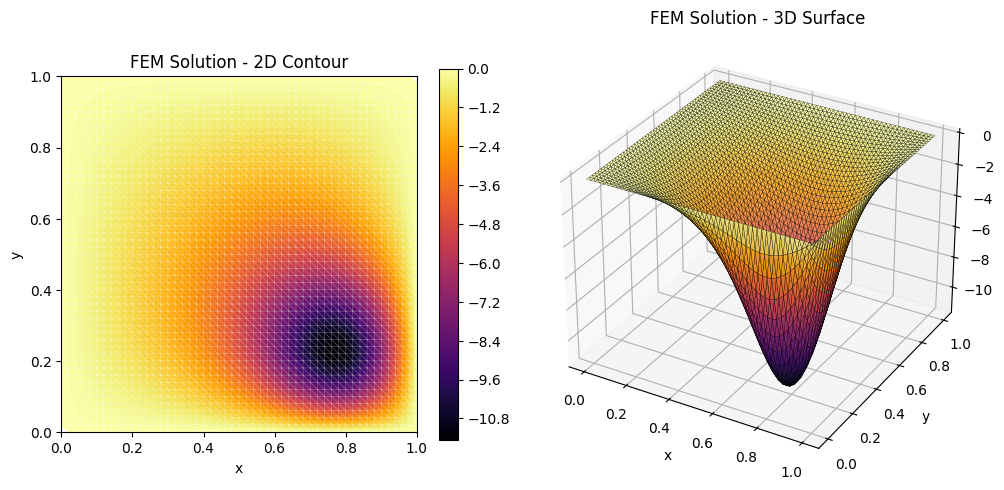

In [3]:
def main():
    def f_func(x, y):  # Source term of Poisson's equation.
        x0, y0 = (0.8, 0.2)
        return - 1e+03 * np.exp(- 40.0 * ((x - x0) ** 2 + (y - y0) ** 2))  # Gaussian function
    
    # Problem parameters
    n_intervals = 50
    
    # 1. Generate mesh
    nodes, elements, boundary_nodes = generate_mesh(n_intervals)
    print(f"Mesh generated: {nodes.shape[0]} nodes, {elements.shape[0]} elements")
    
    # 2. Assemble global system
    K, F, free_nodes = assemble_global_system(nodes, elements, boundary_nodes, f_func)
    print(f"System assembled: {K.shape[0]} free nodes, {K.nnz} non-zero entries")
    
    # 3. Solve system
    u_solution = solve_poisson(K, F)
    print(f"Solution computed: min = {u_solution.min():.4f}, max = {u_solution.max():.4f}")
    
    # 4. Plot results
    plot_solution(nodes, elements, free_nodes, u_solution)

main()

Scikit-fem computed solution (much efficient)

In [4]:
# Importing skfem staff
from skfem import MeshTri, ElementTriP1, Basis, BilinearForm, LinearForm, solve, condense
from skfem.helpers import dot, grad

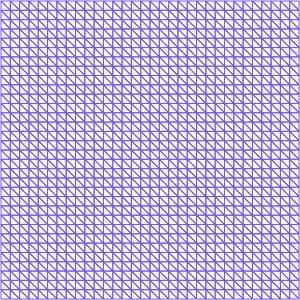

In [5]:
# 1. Mesh and Basis
mesh = MeshTri().refined(5)
basis = Basis(mesh, ElementTriP1())

mesh

In [6]:
basis

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 2048
  Number of DOFs: 1089
  Size: 442368 B

In [7]:
# 2. Define the weak form: Integral(grad(u) * grad(v))
@BilinearForm
def laplace(u, v, _):
    return dot(grad(u), grad(v))

# 3. Define the load f(x, y)
@LinearForm
def rhs(v, w):
    x, y = w.x
    x0, y0 = (0.8, 0.2)
    f = - 1e+03 * np.exp(- 40.0 * ((x - x0) ** 2 + (y - y0) ** 2))  # Gaussian function
    return f * v

In [8]:
# 4. Assembly
A = laplace.assemble(basis)
b = rhs.assemble(basis)

A, b

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 5313 stored elements and shape (1089, 1089)>,
 array([-5.01528337e-13, -1.93197041e-02, -1.17274163e-22, ...,
        -1.18621053e-04, -1.61576080e-04, -3.70959323e-05], shape=(1089,)))

In [9]:
# 5. Boundary Conditions
D = basis.get_dofs() # basis.get_dofs() identifies all nodes on the boundary
D

<skfem DofsView(MeshTri1, ElementTriP1) object>
  Number of nodal DOFs: 128 ['u']

In [10]:
# 6. Solve the problem
u_solution = solve(*condense(A, b, D = D))
u_solution

array([ 0.        ,  0.        ,  0.        , ..., -2.49378953,
       -2.47261014, -2.16737983], shape=(1089,))

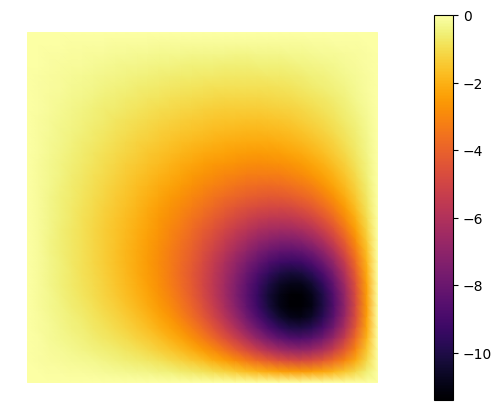

Solution computed: min = -11.3973, max = 0.0000


In [11]:
# 7. Plot the solution
mesh.plot(u_solution,
          shading = 'gouraud',
          colorbar = True,
          cmap = 'inferno',
          figsize = (10, 5)).show()

print(f"Solution computed: min = {u_solution.min():.4f}, max = {u_solution.max():.4f}")